In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

In [7]:
train_dir = "data/train/rgb-front"
train_labels = "data/train/labels.csv"

id_dir = "data/test/rgb-front"
id_labels = "data/test/labels.csv"

fog_dir = "fog_data/test-fog/rgb-front"
fog_labels = "fog_data/test-fog/labels.csv"

night_dir = "night_data/test-night/rgb-front"
night_labels = "night_data/test-night/labels.csv"

town_dir = "test-town-01/rgb-front"
town_labels = "test-town-01/labels.csv"

In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
def get_samples(folder, n=5):
    files = sorted(os.listdir(folder))[:n]
    return [os.path.join(folder, f) for f in files]

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def load_images(folder, n=5):
    files = sorted(os.listdir(folder))[:n]
    images = []
    for f in files:
        path = os.path.join(folder, f)
        try:
            img = Image.open(path).convert("RGB")
            images.append(img)
        except Exception as e:
            print("Error:", path, e)
    return images

In [10]:
id_imgs = load_images(id_dir, 5)
fog_imgs = load_images(fog_dir, 5)
night_imgs = load_images(night_dir, 5)
town_imgs = load_images(town_dir, 5)

This shows 5 images per domain clearly

In [11]:
def plot_images(images, title):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title)

    for i, img in enumerate(images):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

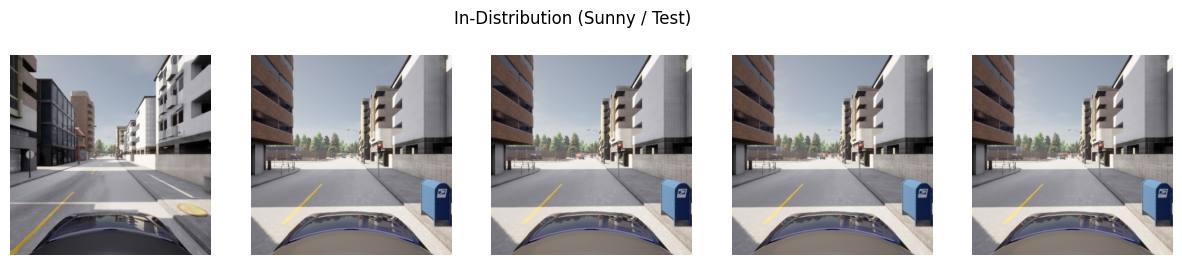

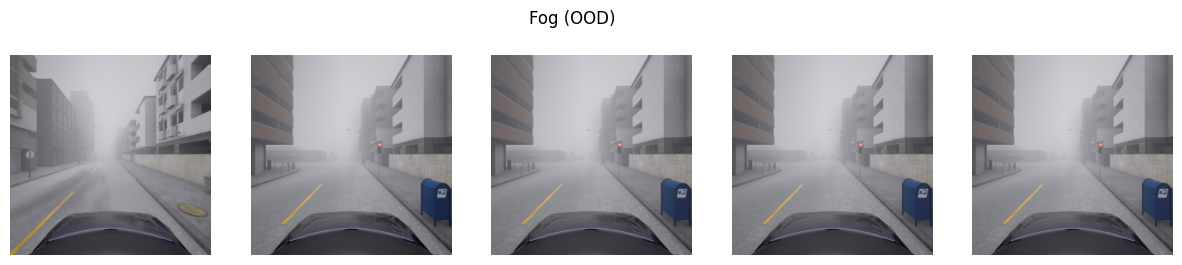

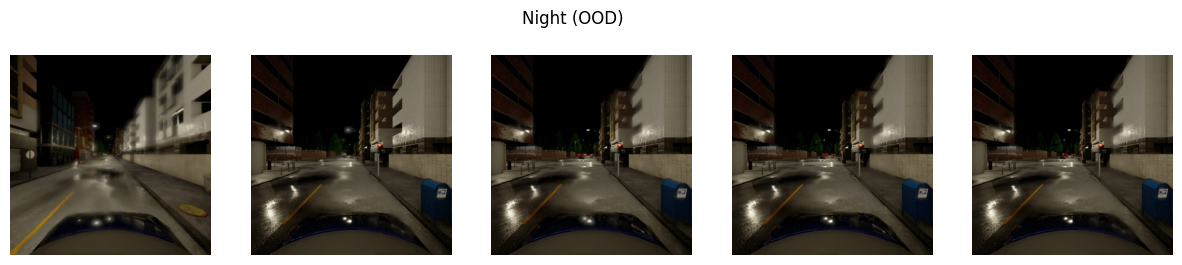

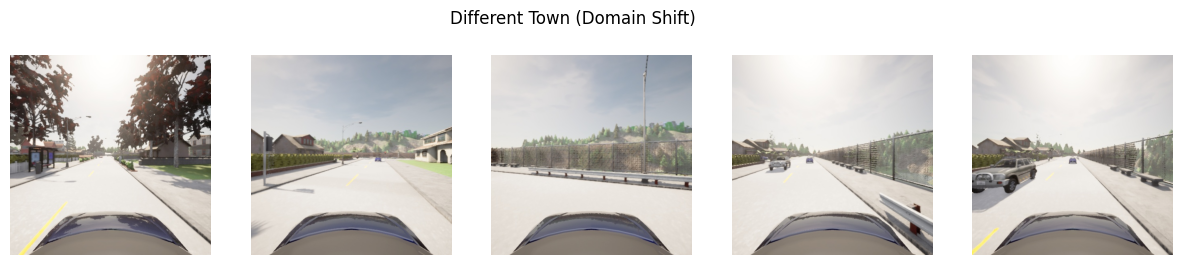

In [13]:
plot_images(id_imgs, "In-Distribution (Sunny / Test)")
plot_images(fog_imgs, "Fog (OOD)")
plot_images(night_imgs, "Night (OOD)")
plot_images(town_imgs, "Different Town (Domain Shift)")


In [36]:
def mean_confidence_ped(model, folder):
    confidences = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output).item()
            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

    return sum(confidences) / len(confidences)

In [37]:
id_folder = "data/test/rgb-front"
fog_folder = "fog_data/test-fog/rgb-front"
night_folder = "night_data/test-night/rgb-front"

In [38]:
import torch
from torchvision import models
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

ped_model = models.resnet18(pretrained=False)
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)

ped_model.load_state_dict(torch.load("ped_model_v2.pth", map_location=device))

ped_model = ped_model.to(device)
ped_model.eval()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_46748\3825920710.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ped_model.load_state_dict(torch.load("ped_model_v2.pth", map

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [39]:
print("Pedestrian Model")
print("ID:", mean_confidence(ped_model, id_folder))
print("Fog:", mean_confidence(ped_model, fog_folder))
print("Night:", mean_confidence(ped_model, night_folder))

Pedestrian Model
ID: 0.910978172954812
Fog: 0.923176294947037
Night: 0.8686464313493182


In [22]:
import torch
print(torch.cuda.is_available())

True


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
import torch
from torchvision.models import resnet18

checkpoint = torch.load("vehicle_model.pth", map_location=device)
vehicle_model = resnet18(pretrained=False)
vehicle_model.fc = torch.nn.Linear(vehicle_model.fc.in_features, 1)
vehicle_model.load_state_dict(checkpoint)
vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_46748\607792702.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("vehicle_model.pth", map_location=devi

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
from PIL import Image
import os

# pick ONE image from fog folder (you can change folder later)
img_name = os.listdir(fog_folder)[0]

img_path = os.path.join(fog_folder, img_name)

img = Image.open(img_path).convert("RGB")

img = transform(img).unsqueeze(0).to(device)

In [31]:
output = vehicle_model(img)
print(output)

tensor([[-1.9628]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [33]:
def mean_confidence(model, folder):
    confidences = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output).item()
            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

    return sum(confidences) / len(confidences)

In [34]:
print("Vehicle Model")
print("ID:", mean_confidence(vehicle_model, id_folder))
print("Fog:", mean_confidence(vehicle_model, fog_folder))
print("Night:", mean_confidence(vehicle_model, night_folder))

Vehicle Model
ID: 0.9141749012976005
Fog: 0.8327182483993885
Night: 0.9721326731815417


In [40]:
from torchvision.models import resnet18
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

traffic_model = resnet18(pretrained=False)
traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)

traffic_model.load_state_dict(torch.load("traffic_light_model.pth", map_location=device))

traffic_model = traffic_model.to(device)
traffic_model.eval()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_46748\3364569319.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  traffic_model.load_state_dict(torch.load("traffic_light_mode

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:
def mean_confidence_traffic(model, folder):
    confidences = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output).item()
            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

    return sum(confidences) / len(confidences)

In [42]:
print("Traffic Light Model")
print("ID:", mean_confidence_traffic(traffic_model, id_folder))
print("Fog:", mean_confidence_traffic(traffic_model, fog_folder))
print("Night:", mean_confidence_traffic(traffic_model, night_folder))

Traffic Light Model
ID: 0.9795415218182141
Fog: 0.7977598730481016
Night: 0.9934218597226203


# 9.4.2

The different-town images have similar weather and lighting conditions to the training data but contain different road layouts, buildings, and vegetation. In contrast, fog and night images introduce significant appearance changes due to reduced visibility and lighting conditions. Therefore, fog and night represent an appearance shift, while the different town represents a structural or domain shift.

# 9.4.3

The confidence values remain high for both in-distribution and OOD images. Some models show reduced confidence under fog conditions, while others remain highly confident even on night images. This suggests that the models are often overconfident on OOD inputs and that confidence alone may not reliably indicate distribution shift.


# 9.5.1

The original ODD does not explicitly mention whether a new unseen town is included. It only defines environmental conditions like weather, lighting, and road type, but not geographical variation.

# 9.5.2

The system operates in daytime, clear-weather urban environments with standard traffic conditions, clean camera input, and moderate vehicle speeds. This includes different urban layouts (different towns) as long as environmental conditions remain similar to training data.

# 9.5.3

The system operates in daytime, clear-weather urban environments with standard traffic conditions, clean camera input, and moderate vehicle speeds. This includes different urban layouts (different towns) as long as environmental conditions remain similar to training data.

# 9.6

In [46]:
def get_msp(model, folder):
    scores = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output)
            msp = max(prob.item(), 1 - prob.item())

            scores.append(msp)

    return np.array(scores)

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [48]:
id_scores = get_msp(vehicle_model, id_folder)
fog_scores = get_msp(vehicle_model, fog_folder)
night_scores = get_msp(vehicle_model, night_folder)
town_scores = get_msp(vehicle_model, town_dir)

ood_scores = np.concatenate([fog_scores, night_scores, town_scores])

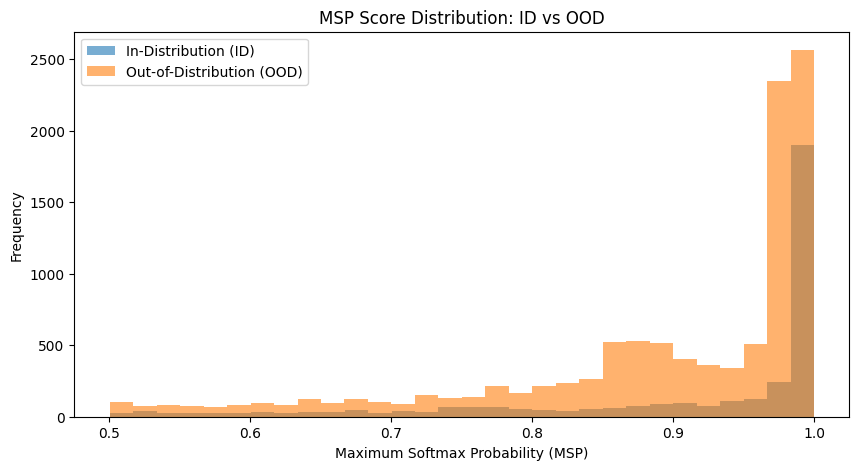

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(id_scores, bins=30, alpha=0.6, label="In-Distribution (ID)")
plt.hist(ood_scores, bins=30, alpha=0.6, label="Out-of-Distribution (OOD)")

plt.title("MSP Score Distribution: ID vs OOD")
plt.xlabel("Maximum Softmax Probability (MSP)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

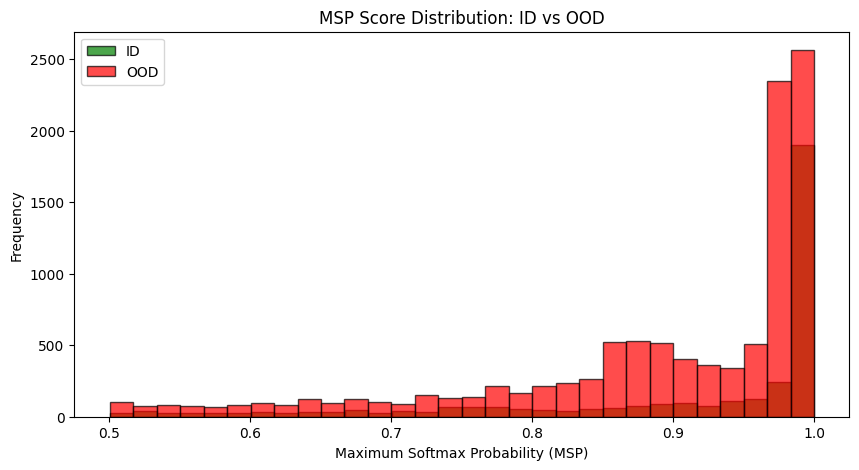

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(id_scores, bins=30, alpha=0.7, label="ID", color="green", edgecolor="black")
plt.hist(ood_scores, bins=30, alpha=0.7, label="OOD", color="red", edgecolor="black")

plt.title("MSP Score Distribution: ID vs OOD")
plt.xlabel("Maximum Softmax Probability (MSP)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

np.concatenate()- Combines multiple arrays into a single array along a specified axis.
np.ones()-Creates an array filled with ones of a given size.
roc_auc_score()-Computes the AUROC score, measuring how well a model separates two classes using prediction scores.

In [50]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.ones(len(id_scores)),   # ID = 1
    np.zeros(len(ood_scores))  # OOD = 0
])

y_scores = np.concatenate([
    id_scores,
    ood_scores
])

auroc = roc_auc_score(y_true, y_scores)

print("AUROC:", auroc)

AUROC: 0.640946116255144


# 9.7

In [52]:
import torch
import numpy as np
from torchvision.models import resnet18
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(pretrained=False)
model.fc = torch.nn.Identity()   # feature extractor

model = model.to(device)
model.eval()

C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [53]:
def extract_features(model, folder):
    features = []

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue
+

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            feat = model(img)
            features.append(feat.cpu().numpy().flatten())

    return np.array(features)+   

In [61]:
id_feat = extract_features(model, id_folder)
fog_feat = extract_features(model, fog_folder)
night_feat = extract_features(model, night_folder)
town_feat = extract_features(model, town_dir)

ood_feat = np.concatenate([fog_feat, night_feat, town_feat])

In [62]:
knn = NearestNeighbors(n_neighbors=5)
knn.fit(id_feat)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [56]:
def knn_score(model_knn, features):
    distances, _ = model_knn.kneighbors(features)
    return distances.mean(axis=1)   # larger distance = more OOD

In [57]:
id_scores_knn = knn_score(knn, id_feat)
ood_scores_knn = knn_score(knn, ood_feat)

In [59]:
y_true = np.concatenate([
    np.ones(len(id_scores_knn)),   # ID = 1
    np.zeros(len(ood_scores_knn))  # OOD = 0
])

y_scores = np.concatenate([
    id_scores_knn,
    ood_scores_knn
])


y_scores = -y_scores

auroc_knn = roc_auc_score(y_true, y_scores)

print("k-NN AUROC:", auroc_knn)

k-NN AUROC: 0.9866573302469135


In [60]:
print("MSP AUROC (from before):", auroc)
print("k-NN AUROC:", auroc_knn)

MSP AUROC (from before): 0.640946116255144
k-NN AUROC: 0.9866573302469135
